## EDA CUSTOMERS ENGAGEMENT BEHAVIOR ANALYSIS 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd
from scipy import stats

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')

In [3]:
engagement_type_data = df[["Login_Frequency", "Pages_Per_Session","Session_Duration_Avg", "Mobile_App_Usage", "Social_Media_Engagement_Score"]]

In [4]:
stats = engagement_type_data.describe().T  # .T = transpose ให้อ่านง่ายขึ้น
stats["skewness"] = engagement_type_data.skew()
stats["kurtosis"] = engagement_type_data.kurt()
stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Login_Frequency,50000.0,11.624660,7.810657,0.0,6.0,11.0,17.0,46.0,0.511945,-0.144381
Pages_Per_Session,50000.0,8.717542,3.663996,1.0,6.2,8.4,11.0,24.1,0.419215,0.074851
Session_Duration_Avg,50000.0,27.602240,10.497234,1.0,20.2,26.8,34.0,75.6,0.431393,0.133731
Mobile_App_Usage,50000.0,19.294446,8.938875,0.0,13.2,18.6,24.6,61.9,0.452248,0.239742
Social_Media_Engagement_Score,50000.0,29.152730,19.308632,0.0,15.3,27.6,40.7,100.0,0.570295,0.150854


Engagement measure by 

    - Login_Frequency (X)

    - Pages_Per_Session (X)

    - Session_Duration_Avg (X)
    
    - Mobile_App_Usage (X)

    - Social_Media_Engagement_Score (X)

### 1) Login Frequency

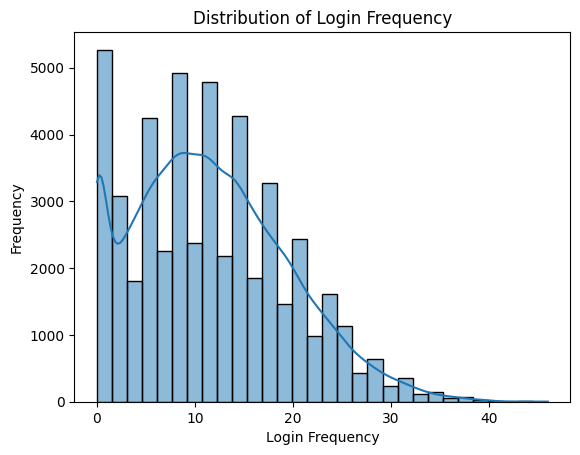

In [5]:
sns.histplot(df["Login_Frequency"], bins=30, kde=True)
plt.title("Distribution of Login Frequency")
plt.xlabel("Login Frequency")
plt.ylabel("Frequency")
plt.show()

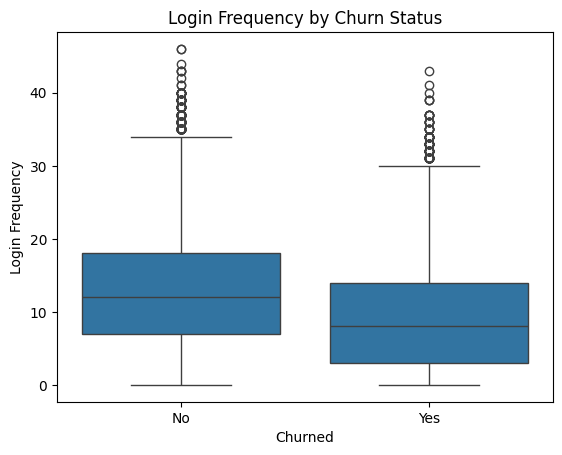

In [6]:
sns.boxplot(data=df, x=df["Churned"].map({1: "Yes", 0: "No"}), y="Login_Frequency")
plt.title("Login Frequency by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Login Frequency")
plt.show()

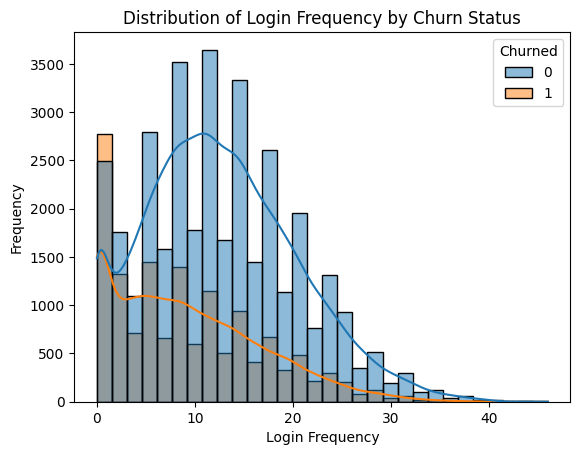

In [7]:
sns.histplot(data=df, x="Login_Frequency", hue="Churned", bins=30, kde=True)
plt.title("Distribution of Login Frequency by Churn Status")
plt.xlabel("Login Frequency")
plt.ylabel("Frequency")
plt.show()

In [13]:

churned = df[df["Churned"] == 1]["Login_Frequency"]
not_churned = df[df["Churned"] == 0]["Login_Frequency"]

t_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print(f"Mann-Whitney U Test: p-value = {p_value:.6f}")

if p_value < 0.05:
    print("มีความแตกต่างอย่างมีนัยสำคัญ")
else:
    print("ไม่มีความแตกต่าง")

Mann-Whitney U Test: p-value = 0.000000
มีความแตกต่างอย่างมีนัยสำคัญ


In [ ]:
Q1 = df["Login_Frequency"].quantile(0.25)
Q3 = df["Login_Frequency"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Login_Frequency"] < Q1 - 1.5 * IQR) | 
              (df["Login_Frequency"] > Q3 + 1.5 * IQR)]
print(f"Outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 309 rows (0.62%)


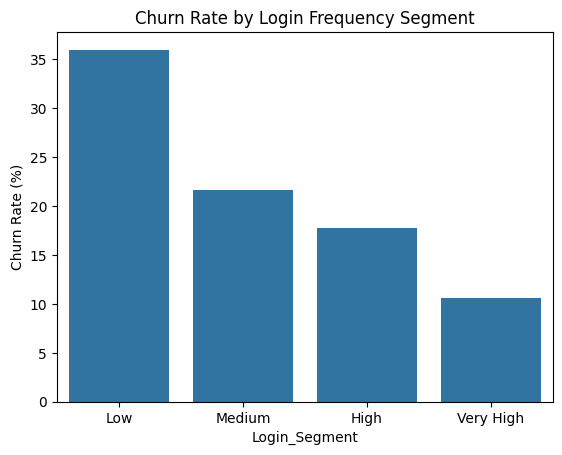

In [ ]:
df["Login_Segment"] = pd.cut(df["Login_Frequency"], 
                              bins=4, 
                              labels=["Low", "Medium", "High", "Very High"])

churn_rate = df.groupby("Login_Segment")["Churned"].mean() * 100

sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Churn Rate by Login Frequency Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

### 2) Pages_Per_Session

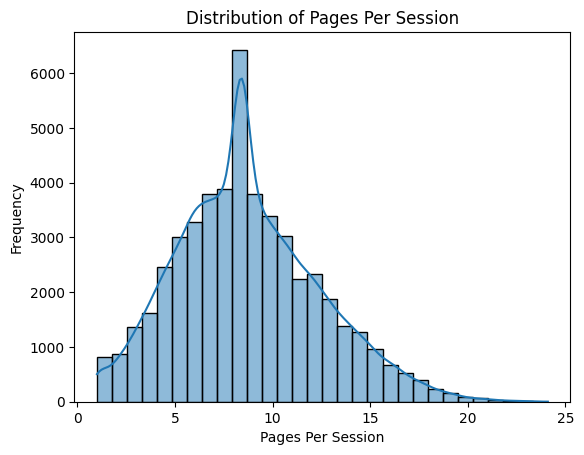

In [10]:
sns.histplot(df["Pages_Per_Session"], bins=30, kde=True)
plt.title("Distribution of Pages Per Session")
plt.xlabel("Pages Per Session")
plt.ylabel("Frequency")
plt.show()

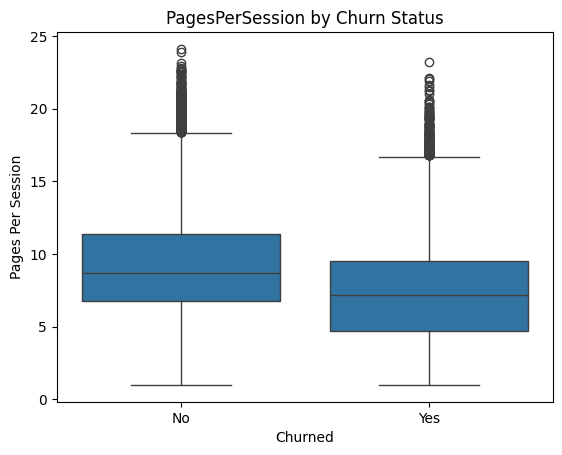

In [14]:
sns.boxplot(data=df, x=df["Churned"].map({1: "Yes", 0: "No"}), y="Pages_Per_Session")
plt.title("PagesPerSession by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Pages Per Session")
plt.show()

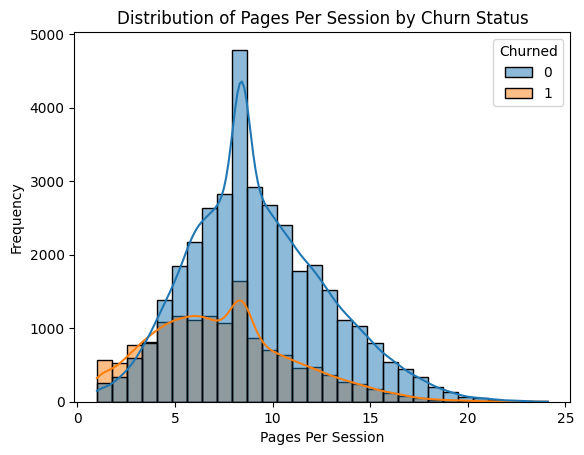

In [15]:
sns.histplot(data=df, x="Pages_Per_Session", hue="Churned", bins=30, kde=True)
plt.title("Distribution of Pages Per Session by Churn Status")
plt.xlabel("Pages Per Session")
plt.ylabel("Frequency")
plt.show()

In [16]:
churned = df[df["Churned"] == 1]["Pages_Per_Session"]
not_churned = df[df["Churned"] == 0]["Pages_Per_Session"]

t_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print(f"Mann-Whitney U Test: p-value = {p_value:.6f}")

if p_value < 0.05:
    print("มีความแตกต่างอย่างมีนัยสำคัญ")
else:
    print("ไม่มีความแตกต่าง")

Mann-Whitney U Test: p-value = 0.000000
มีความแตกต่างอย่างมีนัยสำคัญ


In [21]:
Q1 = df["Pages_Per_Session"].quantile(0.25)
Q3 = df["Pages_Per_Session"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Pages_Per_Session"] < Q1 - 1.5 * IQR) | 
              (df["Pages_Per_Session"] > Q3 + 1.5 * IQR)]
print(f"Outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 478 rows (0.96%)


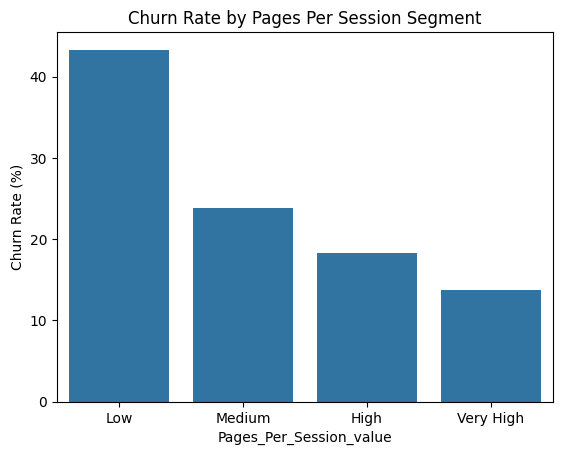

In [22]:
df["Pages_Per_Session_value"] = pd.cut(df["Pages_Per_Session"], 
                              bins=4, 
                              labels=["Low", "Medium", "High", "Very High"])

churn_rate = df.groupby("Pages_Per_Session_value")["Churned"].mean() * 100

sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Churn Rate by Pages Per Session Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

### 3) Session_Duration_Avg


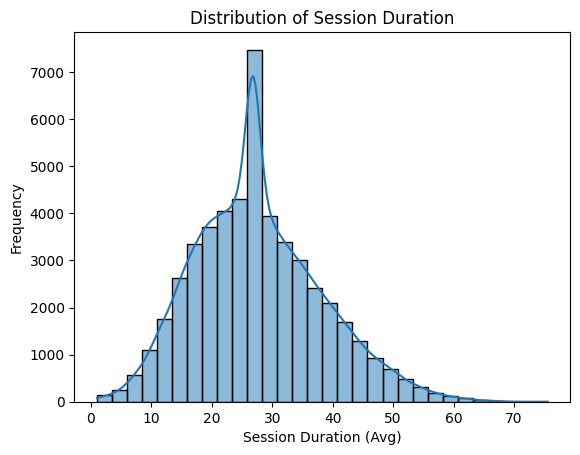

In [25]:
sns.histplot(df["Session_Duration_Avg"], bins=30, kde=True)
plt.title("Distribution of Session Duration")
plt.xlabel("Session Duration (Avg)")
plt.ylabel("Frequency")
plt.show()

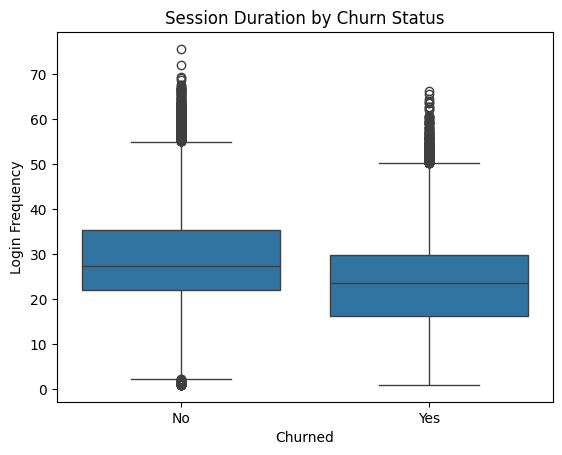

In [26]:
sns.boxplot(data=df, x=df["Churned"].map({1: "Yes", 0: "No"}), y="Session_Duration_Avg")
plt.title("Session Duration by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Login Frequency")
plt.show()

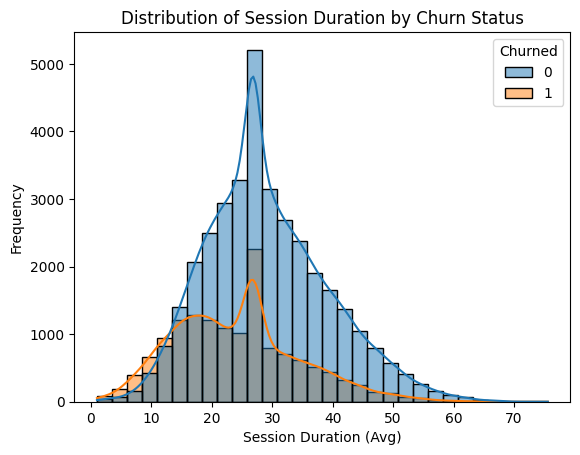

In [27]:
sns.histplot(data=df, x="Session_Duration_Avg", hue="Churned", bins=30, kde=True)
plt.title("Distribution of Session Duration by Churn Status")
plt.xlabel("Session Duration (Avg)")
plt.ylabel("Frequency")
plt.show()

In [28]:
churned = df[df["Churned"] == 1]["Session_Duration_Avg"]
not_churned = df[df["Churned"] == 0]["Session_Duration_Avg"]

t_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print(f"Mann-Whitney U Test: p-value = {p_value:.6f}")

if p_value < 0.05:
    print("มีความแตกต่างอย่างมีนัยสำคัญในระยะเวลาการใช้งานเฉลี่ย")
else:
    print("ไม่มีความแตกต่าง")

Mann-Whitney U Test: p-value = 0.000000
มีความแตกต่างอย่างมีนัยสำคัญในระยะเวลาการใช้งานเฉลี่ย


In [29]:
Q1 = df["Session_Duration_Avg"].quantile(0.25)
Q3 = df["Session_Duration_Avg"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Session_Duration_Avg"] < Q1 - 1.5 * IQR) | 
              (df["Session_Duration_Avg"] > Q3 + 1.5 * IQR)]
print(f"Outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 529 rows (1.06%)


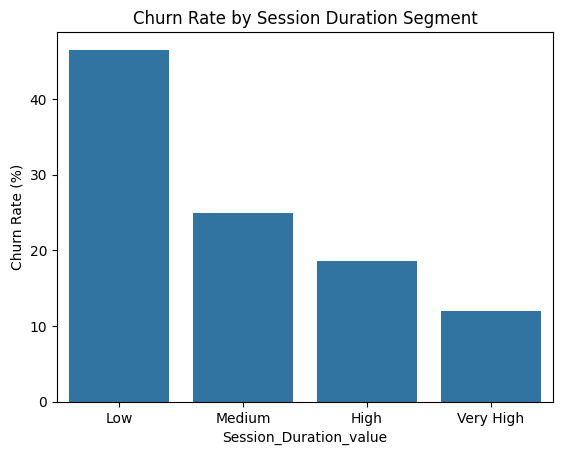

In [30]:
df["Session_Duration_value"] = pd.cut(df["Session_Duration_Avg"], 
                              bins=4, 
                              labels=["Low", "Medium", "High", "Very High"])

churn_rate = df.groupby("Session_Duration_value")["Churned"].mean() * 100

sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Churn Rate by Session Duration Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

### 4) Mobile_App_Usage

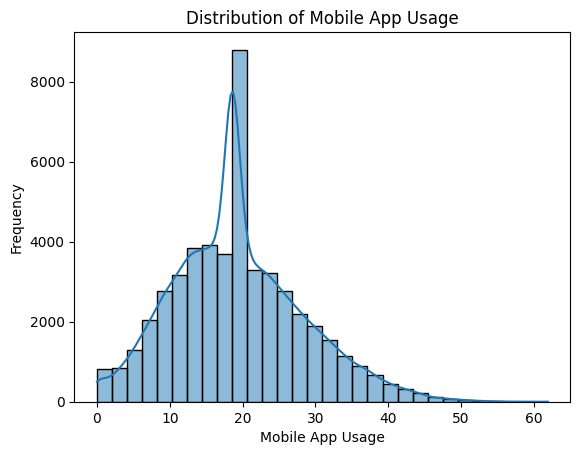

In [31]:
sns.histplot(df["Mobile_App_Usage"], bins=30, kde=True)
plt.title("Distribution of Mobile App Usage")
plt.xlabel("Mobile App Usage")
plt.ylabel("Frequency")
plt.show()

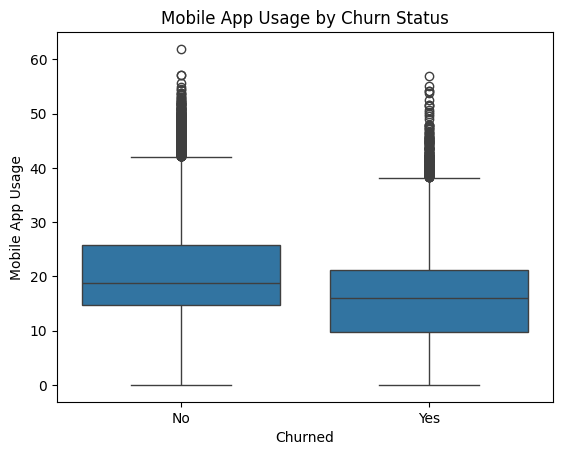

In [32]:
sns.boxplot(data=df, x=df["Churned"].map({1: "Yes", 0: "No"}), y="Mobile_App_Usage")
plt.title("Mobile App Usage by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Mobile App Usage")
plt.show()

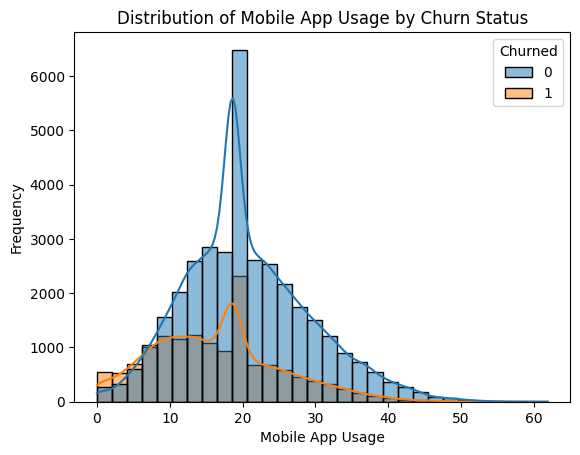

In [33]:
sns.histplot(data=df, x="Mobile_App_Usage", hue="Churned", bins=30, kde=True)
plt.title("Distribution of Mobile App Usage by Churn Status")
plt.xlabel("Mobile App Usage")
plt.ylabel("Frequency")
plt.show()

In [34]:
churned = df[df["Churned"] == 1]["Mobile_App_Usage"]
not_churned = df[df["Churned"] == 0]["Mobile_App_Usage"]

t_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print(f"Mann-Whitney U Test: p-value = {p_value:.6f}")

if p_value < 0.05:
    print("มีความแตกต่างอย่างมีนัยสำคัญใน Mobile App Usage")
else:
    print("ไม่มีความแตกต่างอย่างมีนัยสำคัญใน Mobile App Usage")

Mann-Whitney U Test: p-value = 0.000000
มีความแตกต่างอย่างมีนัยสำคัญใน Mobile App Usage


In [35]:
Q1 = df["Mobile_App_Usage"].quantile(0.25)
Q3 = df["Mobile_App_Usage"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Mobile_App_Usage"] < Q1 - 1.5 * IQR) | 
              (df["Mobile_App_Usage"] > Q3 + 1.5 * IQR)]
print(f"Outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 692 rows (1.38%)


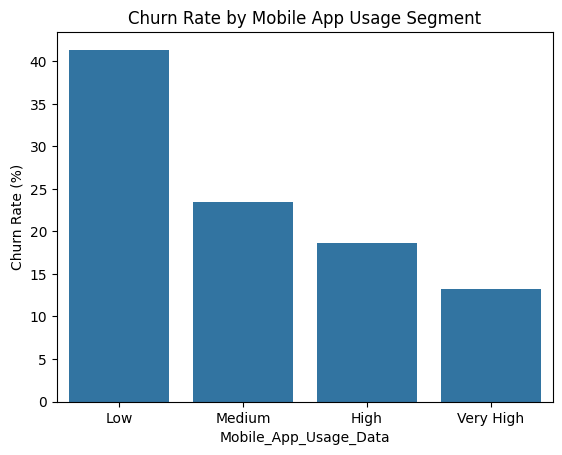

In [36]:
df["Mobile_App_Usage_Data"] = pd.cut(df["Mobile_App_Usage"], 
                              bins=4, 
                              labels=["Low", "Medium", "High", "Very High"])

churn_rate = df.groupby("Mobile_App_Usage_Data")["Churned"].mean() * 100

sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Churn Rate by Mobile App Usage Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

### 5) Social_Media_Engagement_Score

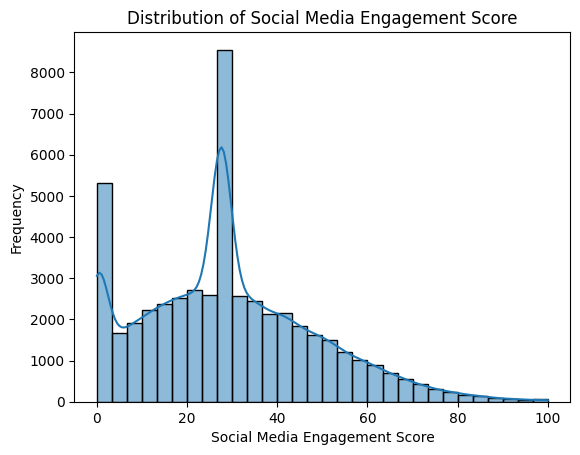

In [37]:
sns.histplot(df["Social_Media_Engagement_Score"], bins=30, kde=True)
plt.title("Distribution of Social Media Engagement Score")
plt.xlabel("Social Media Engagement Score")
plt.ylabel("Frequency")
plt.show()

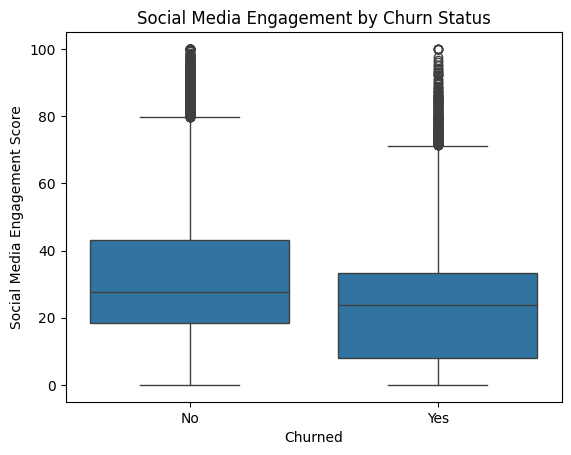

In [38]:
sns.boxplot(data=df, x=df["Churned"].map({1: "Yes", 0: "No"}), y="Social_Media_Engagement_Score")
plt.title("Social Media Engagement by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Social Media Engagement Score")
plt.show()

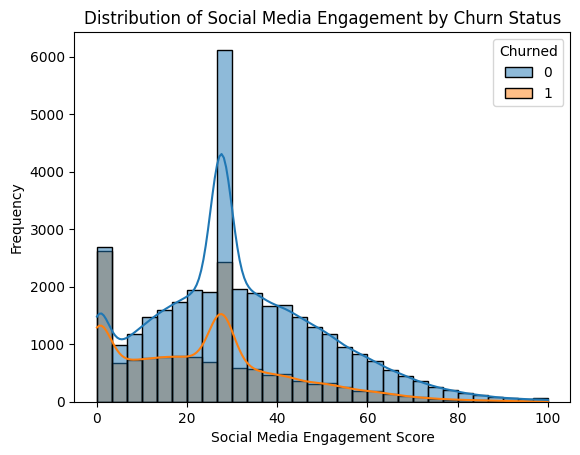

In [39]:
sns.histplot(data=df, x="Social_Media_Engagement_Score", hue="Churned", bins=30, kde=True)
plt.title("Distribution of Social Media Engagement by Churn Status")
plt.xlabel("Social Media Engagement Score")
plt.ylabel("Frequency")
plt.show()

In [40]:
churned = df[df["Churned"] == 1]["Social_Media_Engagement_Score"]
not_churned = df[df["Churned"] == 0]["Social_Media_Engagement_Score"]

t_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print(f"Mann-Whitney U Test: p-value = {p_value:.6f}")

if p_value < 0.05:
    print("มีความแตกต่างอย่างมีนัยสำคัญใน Social Media Engagement")
else:
    print("ไม่มีความแตกต่างอย่างมีนัยสำคัญใน Social Media Engagement")

Mann-Whitney U Test: p-value = 0.000000
มีความแตกต่างอย่างมีนัยสำคัญใน Social Media Engagement


In [41]:
Q1 = df["Social_Media_Engagement_Score"].quantile(0.25)
Q3 = df["Social_Media_Engagement_Score"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Social_Media_Engagement_Score"] < Q1 - 1.5 * IQR) | 
              (df["Social_Media_Engagement_Score"] > Q3 + 1.5 * IQR)]
print(f"Outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 676 rows (1.35%)


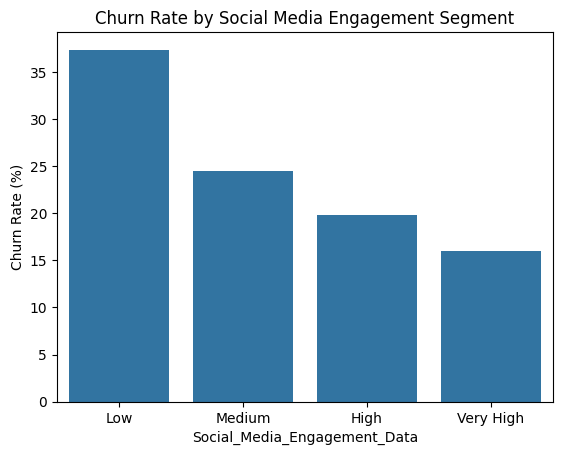

In [42]:
df["Social_Media_Engagement_Data"] = pd.cut(df["Social_Media_Engagement_Score"], 
                              bins=4, 
                              labels=["Low", "Medium", "High", "Very High"])

churn_rate = df.groupby("Social_Media_Engagement_Data")["Churned"].mean() * 100

sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Churn Rate by Social Media Engagement Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

### Check Corrrleation between each other

In [46]:
df[["Login_Frequency","Pages_Per_Session","Session_Duration_Avg","Mobile_App_Usage","Social_Media_Engagement_Score"]].corr()

,Login_Frequency,Pages_Per_Session,Session_Duration_Avg,Mobile_App_Usage,Social_Media_Engagement_Score
Login_Frequency,1.000000,0.654605,0.685319,0.639903,0.547805
Pages_Per_Session,0.654605,1.000000,0.714086,0.665697,0.569395
Session_Duration_Avg,0.685319,0.714086,1.000000,0.698572,0.600677
Mobile_App_Usage,0.639903,0.665697,0.698572,1.000000,0.558500
Social_Media_Engagement_Score,0.547805,0.569395,0.600677,0.558500,1.000000


Session_Duration_Avg เป็นตัวกลางของ engagement

เพราะมันสัมพันธ์กับหลายตัว

    - Login_Frequency → 0.68

    - Pages_Per_Session → 0.71

    - Mobile_App_Usage → 0.69

แปลว่า = คนที่อยู่ในระบบนาน มักจะ engage กับ platform มากขึ้น

Users with shorter session duration and lower login frequency are significantly more likely to churn.

### Insight

User Engagement Analysis

Engagement metrics such as login frequency, pages per session, and session duration show moderate to strong positive correlations (0.54–0.71). This suggests that users who interact more with the platform in one dimension tend to engage more across other dimensions as well. Among these variables, session duration appears to play a central role, showing the strongest correlations with other engagement indicators. This indicates that the amount of time users spend on the platform may be a key driver of overall engagement.